# Pixels-to-predictions data analysis

Targeted EDA — written after the modeling phase to investigate specific failure modes seen in v1-v5:
- Why does test consistently score 4-5 points above val?
- What's special about the 5-choice questions that the model can't crack?
- What's behind the persistent 0↔1, 1↔2 off-by-one confusion?
- Are train/val/test actually drawn from the same distribution?

## 0. Original checks (kept from initial pass)

In [1]:
import pandas as pd
df = pd.read_csv("pixels-to-predictions/train.csv")
print(df.shape)
print(df.dtypes)
print(df.head(3).to_dict(orient="records"))
print(df.isna().sum())

(3109, 15)
id             object
image_path     object
question       object
choices        object
num_choices     int64
answer          int64
hint           object
lecture        object
solution       object
task           object
grade          object
subject        object
topic          object
category       object
skill          object
dtype: object
[{'id': 'train_07667', 'image_path': 'images/train/train_07667.png', 'question': 'Why might putting each tadpole in its own pool of water increase the reproductive success of a male Amazonian poison frog? Complete the claim below that answers this question and is best supported by the passage.\nPutting each tadpole in its own pool of water increases the chances that ().', 'choices': '["the male\'s tadpoles will be larger when they hatch", "the male will carry his tadpoles through the forest", "the male\'s tadpoles will become adult frogs"]', 'num_choices': 3, 'answer': 2, 'hint': "Animals often behave in certain ways that can increase th

In [2]:
for name in ["val", "test"]:
    df = pd.read_csv(f"pixels-to-predictions/{name}.csv")
    print(name, df.shape)
    print(df.columns.tolist())
    print(df.head(2).to_dict(orient="records"))
    print(df.isna().sum())

val (1048, 15)
['id', 'image_path', 'question', 'choices', 'num_choices', 'answer', 'hint', 'lecture', 'solution', 'task', 'grade', 'subject', 'topic', 'category', 'skill']
[{'id': 'val_00671', 'image_path': 'images/val/val_00671.png', 'question': 'Why might covering its eggs with its body increase the reproductive success of a snail leech? Complete the claim below that answers this question and is best supported by the passage.\nCovering its eggs with its body increases the chances that ().', 'choices': '["the leech\'s eggs will hatch", "the leech will not eat for up to a week", "the leech will fight a water snail"]', 'num_choices': 3, 'answer': 0, 'hint': 'Animals often behave in certain ways that can increase their reproductive success. Read the passage about a specific animal behavior. Then, follow the instructions below.\n\nThe snail leech is a type of worm that often lives in freshwater streams. After  reproduces, it attaches its eggs to a rock at the bottom of the stream. The le

In [3]:
from pathlib import Path
from PIL import Image
import random
paths = list(Path("pixels-to-predictions/images/train").rglob("*"))
print(len(paths), "files")
print({p.suffix.lower() for p in paths})
sizes = [Image.open(p).size for p in random.sample(paths, 20)]
print("sample sizes:", sizes)

3109 files
{'.png'}
sample sizes: [(312, 237), (705, 411), (162, 162), (728, 174), (162, 162), (550, 405), (331, 152), (518, 127), (518, 80), (378, 249), (728, 266), (714, 595), (563, 405), (750, 429), (760, 506), (550, 405), (563, 405), (322, 291), (162, 162), (162, 162)]


In [4]:
for split in ["val", "test"]:
    paths = list(Path(f"pixels-to-predictions/images/{split}").rglob("*"))
    print(split, len(paths), {p.suffix.lower() for p in paths})

val 1048 {'.png'}
test 1008 {'.png'}


In [5]:
df = pd.read_csv("pixels-to-predictions/train.csv")
print(df.num_choices.value_counts().sort_index())
print(df.answer.value_counts().sort_index())
print(df.subject.value_counts())

num_choices
2     664
3    1552
4     783
5     110
Name: count, dtype: int64
answer
0    1124
1    1028
2     737
3     204
4      16
Name: count, dtype: int64
subject
natural science     2264
social science       768
language science      77
Name: count, dtype: int64


## 1. Imports for analysis

In [6]:
import json
from pathlib import Path
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

DATA_ROOT = Path("pixels-to-predictions")

def load_split(name):
    df = pd.read_csv(DATA_ROOT / f"{name}.csv")
    df["choices"] = df["choices"].apply(json.loads)
    df["split"] = name
    return df

train = load_split("train")
val   = load_split("val")
test  = load_split("test")
print(f"train={len(train)}  val={len(val)}  test={len(test)}")

train=3109  val=1048  test=1008


## 2. Missing values — double-check there's nothing critical missing

Already-known: hint/lecture/solution are sparse. Confirm that no *required* field is ever missing.

In [7]:
required = ["id", "image_path", "question", "choices", "num_choices"]
for df, name in [(train, "train"), (val, "val"), (test, "test")]:
    print(f"\n--- {name} ---")
    print(df[required + (["answer"] if "answer" in df.columns else [])].isna().sum())
    # Also check whether any choices list is empty (would silently break inference)
    empty_choices = df[df["choices"].apply(lambda c: len(c) == 0)]
    print(f"empty-choices rows: {len(empty_choices)}")
    # And whether num_choices matches len(choices)
    mismatch = df[df.apply(lambda r: r["num_choices"] != len(r["choices"]), axis=1)]
    print(f"num_choices != len(choices): {len(mismatch)}")


--- train ---
id             0
image_path     0
question       0
choices        0
num_choices    0
answer         0
dtype: int64
empty-choices rows: 0
num_choices != len(choices): 0

--- val ---
id             0
image_path     0
question       0
choices        0
num_choices    0
answer         0
dtype: int64
empty-choices rows: 0
num_choices != len(choices): 0

--- test ---
id             0
image_path     0
question       0
choices        0
num_choices    0
dtype: int64
empty-choices rows: 0
num_choices != len(choices): 0


## 3. Distribution drift between splits

This is the big one. If val and test are drawn from genuinely different distributions, the val→test gap we keep seeing has a structural cause, not just luck.

In [8]:
def dist_table(col):
    rows = []
    for df, name in [(train, "train"), (val, "val"), (test, "test")]:
        if col in df.columns:
            counts = df[col].value_counts(normalize=True).sort_index()
            rows.append(counts.rename(name))
    return pd.concat(rows, axis=1).fillna(0).round(4)

for col in ["num_choices", "subject", "task", "grade"]:
    print(f"\n=== {col} ===")
    print(dist_table(col))


=== num_choices ===
              train     val    test
num_choices                        
2            0.2136  0.2328  0.2698
3            0.4992  0.4847  0.4345
4            0.2518  0.2405  0.2579
5            0.0354  0.0420  0.0377

=== subject ===
                   train     val    test
subject                                 
language science  0.0248  0.0267  0.0268
natural science   0.7282  0.7414  0.7321
social science    0.2470  0.2319  0.2411

=== task ===
                train     val    test
task                                 
closed choice  0.9878  0.9685  0.9633
true-or false  0.0122  0.0315  0.0327
yes or no      0.0000  0.0000  0.0040

=== grade ===
          train     val    test
grade                          
grade1   0.0016  0.0010  0.0020
grade12  0.0068  0.0076  0.0050
grade2   0.0370  0.0344  0.0208
grade3   0.0930  0.1011  0.1042
grade4   0.1557  0.1641  0.1577
grade5   0.1139  0.1135  0.1141
grade6   0.1965  0.1832  0.1915
grade7   0.1753  0.1737  0.1716
gr

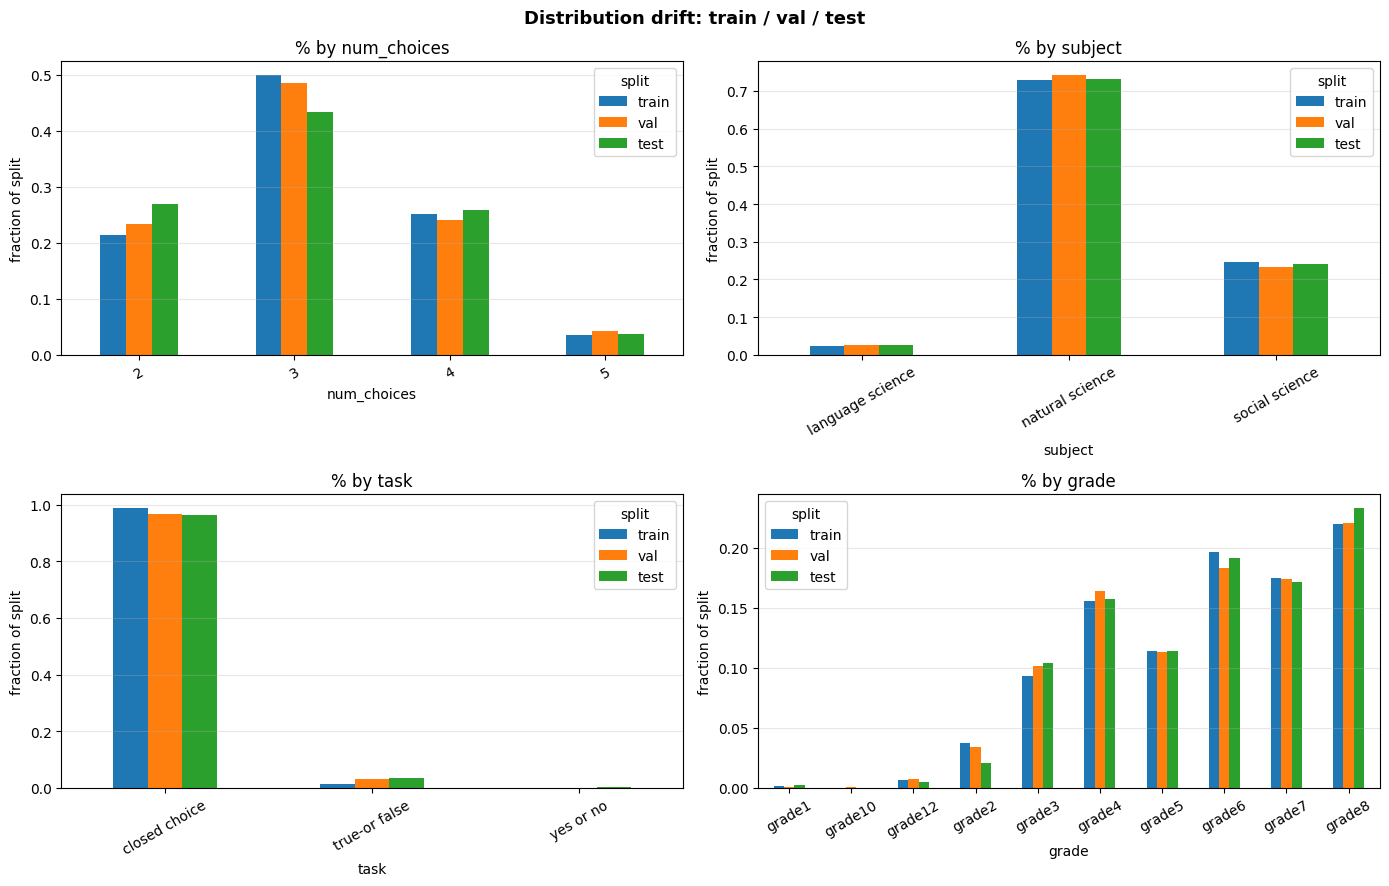

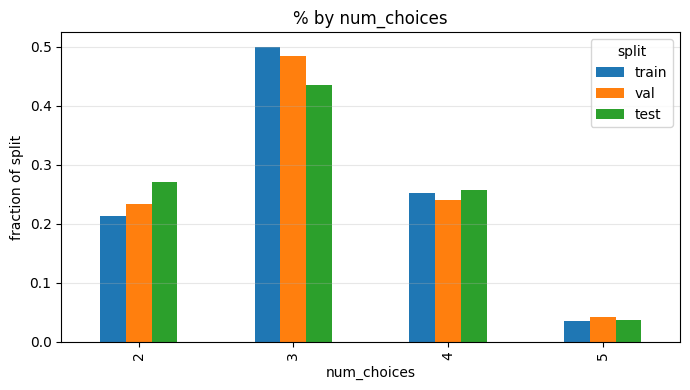

In [9]:
# Same plot, visually
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Distribution drift: train / val / test", fontsize=13, fontweight="bold")

for ax, col in zip(axes.flat, ["num_choices", "subject", "task", "grade"]):
    df_combined = pd.concat([train.assign(split="train"),
                              val.assign(split="val"),
                              test.assign(split="test")])
    pct = (df_combined.groupby(["split", col]).size()
           / df_combined.groupby("split").size()).unstack(fill_value=0)
    pct = pct.loc[["train", "val", "test"]]
    pct.T.plot(kind="bar", ax=ax)
    ax.set_title(f"% by {col}")
    ax.set_ylabel("fraction of split"); ax.set_xlabel(col)
    ax.legend(title="split")
    ax.tick_params(axis="x", rotation=30)
    ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("dist_drift.png", dpi=120, bbox_inches="tight")

# Just save the num_choices panel (top-left of the 4-panel figure)
fig_nc, ax_nc = plt.subplots(figsize=(7, 4))
nc_data = pd.DataFrame({
    "train": train.num_choices.value_counts(normalize=True).sort_index(),
    "val":   val.num_choices.value_counts(normalize=True).sort_index(),
    "test":  test.num_choices.value_counts(normalize=True).sort_index(),
})
nc_data.plot(kind="bar", ax=ax_nc)
ax_nc.set_xlabel("num_choices")
ax_nc.set_ylabel("fraction of split")
ax_nc.set_title("% by num_choices")
ax_nc.legend(title="split")
ax_nc.grid(axis="y", alpha=0.3)
plt.tight_layout()
fig_nc.savefig("data_numchoices_drift.png", dpi=120, bbox_inches="tight")

plt.show()

## 4. Answer index distribution — train vs val

Test has no answer column, but checking train vs val tells us whether the val target is sampled the same way as the training target.

Answer-index distribution (fraction of split):
         train     val
answer                
0       0.3615  0.3311
1       0.3307  0.3550
2       0.2371  0.2357
3       0.0656  0.0716
4       0.0051  0.0067


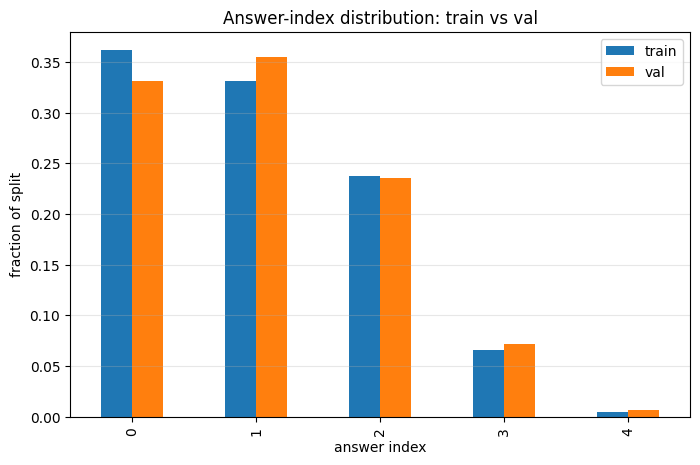

In [10]:
ans_train = train.answer.value_counts(normalize=True).sort_index()
ans_val   = val.answer.value_counts(normalize=True).sort_index()
df_ans = pd.concat([ans_train.rename("train"), ans_val.rename("val")], axis=1).fillna(0).round(4)
print("Answer-index distribution (fraction of split):")
print(df_ans)

fig, ax = plt.subplots(figsize=(8, 5))
df_ans.plot(kind="bar", ax=ax)
ax.set_title("Answer-index distribution: train vs val")
ax.set_xlabel("answer index"); ax.set_ylabel("fraction of split")
ax.grid(axis="y", alpha=0.3)
plt.savefig("answer_dist.png", dpi=120, bbox_inches="tight")
plt.show()

## 5. Text length analysis — are we truncating prompts?

Our final config used `max_text_tokens=1280`. If a meaningful fraction of train/val rows produce prompts longer than that (after the chat template adds boilerplate, image-token placeholders, etc.), the model never sees the end of those examples and we have a silent failure.

Approximation: we don't have the tokenizer here, but ~4 chars/token is a reasonable lower bound for English prose. So 1280 tokens ≈ 5000 chars of text. That's the threshold we want to be well under.

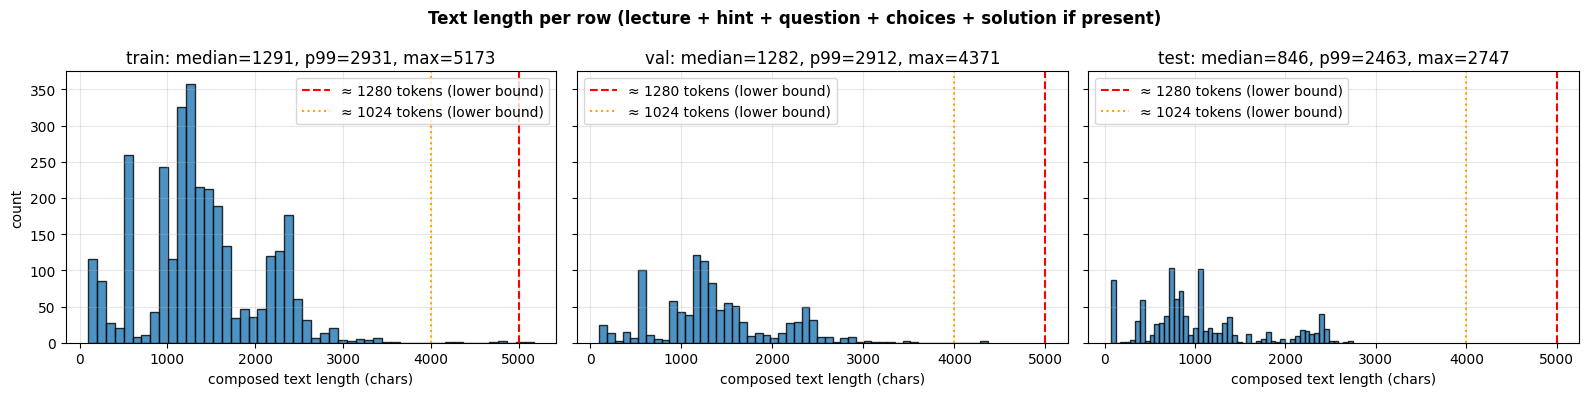


Rows over 5000 chars (likely truncated at 1280 tokens):
  train: 2 of 3109 (0.1%)
  val: 0 of 1048 (0.0%)
  test: 0 of 1008 (0.0%)


In [11]:
def composed_len(row):
    parts = []
    for col in ["lecture", "hint", "question"]:
        v = row.get(col)
        if isinstance(v, str): parts.append(v)
    parts.append(" ".join(row["choices"]))
    if isinstance(row.get("solution"), str):
        parts.append(row["solution"])
    return len(" ".join(parts))

train["text_chars"] = train.apply(composed_len, axis=1)
val["text_chars"]   = val.apply(composed_len, axis=1)
test["text_chars"]  = test.apply(composed_len, axis=1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, (df, name) in zip(axes, [(train, "train"), (val, "val"), (test, "test")]):
    ax.hist(df["text_chars"], bins=50, edgecolor="black", alpha=0.8)
    ax.axvline(5000, color="red", ls="--", label="≈ 1280 tokens (lower bound)")
    ax.axvline(4000, color="orange", ls=":", label="≈ 1024 tokens (lower bound)")
    p99 = df["text_chars"].quantile(0.99)
    pmax = df["text_chars"].max()
    ax.set_title(f"{name}: median={int(df.text_chars.median())}, "
                 f"p99={int(p99)}, max={int(pmax)}")
    ax.set_xlabel("composed text length (chars)"); ax.legend()
    ax.grid(alpha=0.3)
axes[0].set_ylabel("count")
plt.suptitle("Text length per row (lecture + hint + question + choices + solution if present)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("text_lengths.png", dpi=120, bbox_inches="tight")
plt.show()

print("\nRows over 5000 chars (likely truncated at 1280 tokens):")
for df, name in [(train, "train"), (val, "val"), (test, "test")]:
    over = (df["text_chars"] > 5000).sum()
    print(f"  {name}: {over} of {len(df)} ({over/len(df):.1%})")

## 6. Image dimension distribution

Looking for extreme aspect ratios (e.g., wide-and-short like 728×174) that get badly distorted by the processor's resize.

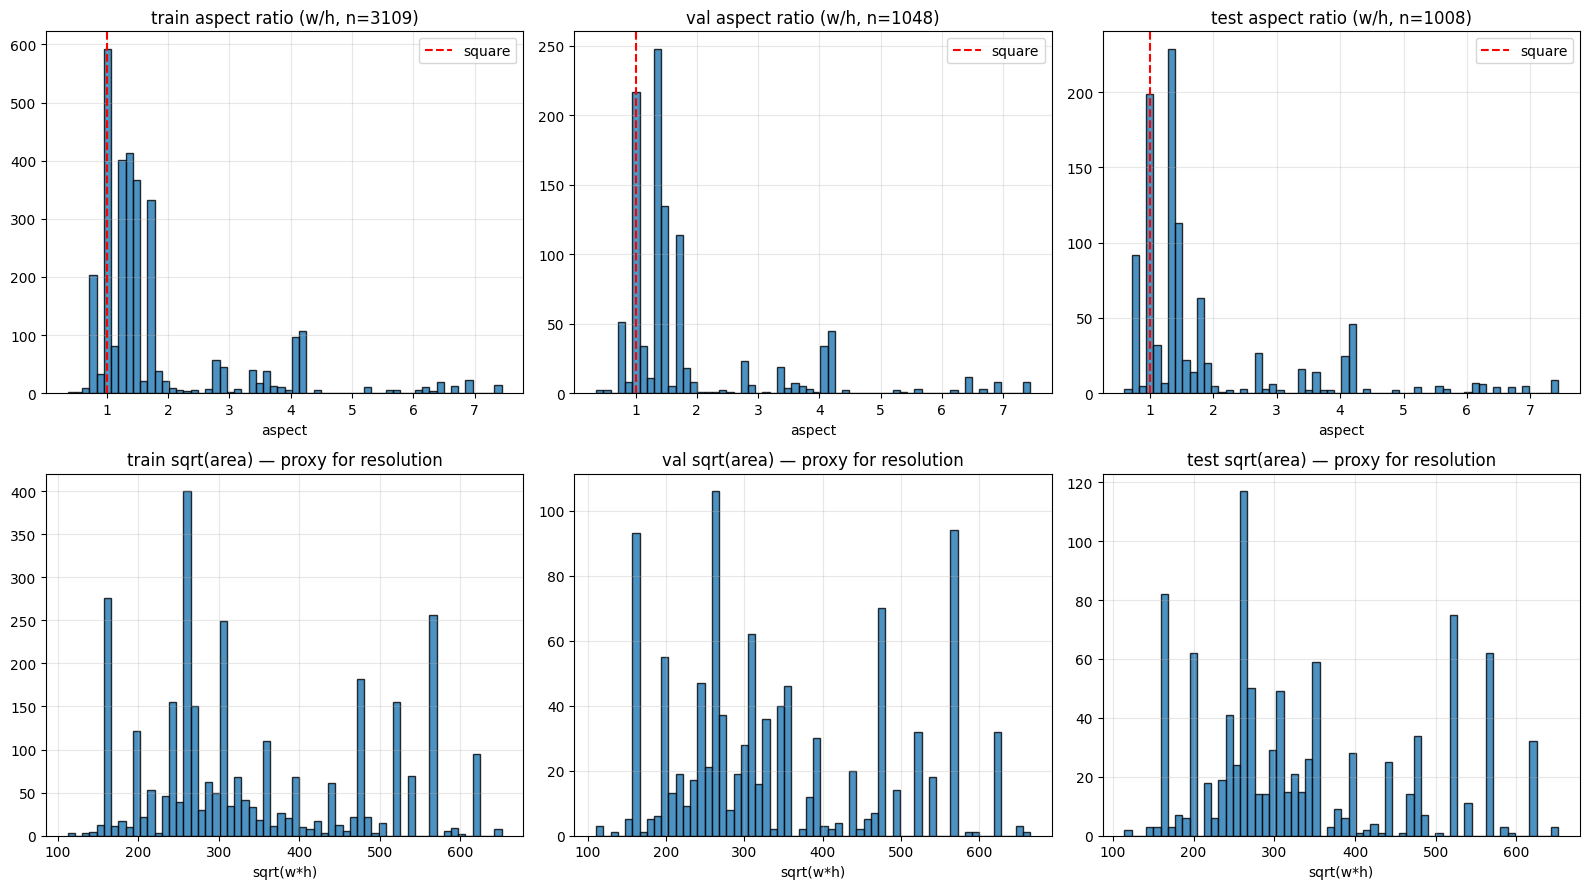

train: 325 images with extreme aspect (<0.4 or >4)
val: 123 images with extreme aspect (<0.4 or >4)
test: 124 images with extreme aspect (<0.4 or >4)


In [12]:
def collect_sizes(split):
    paths = sorted((DATA_ROOT / "images" / split).glob("*.png"))
    sizes = []
    for p in paths:
        with Image.open(p) as im:
            sizes.append((p.stem, im.size[0], im.size[1]))
    return pd.DataFrame(sizes, columns=["id", "w", "h"]).assign(
        aspect=lambda d: d.w / d.h, area=lambda d: d.w * d.h)

img_train = collect_sizes("train")
img_val   = collect_sizes("val")
img_test  = collect_sizes("test")

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for col, (df, name) in enumerate([(img_train, "train"), (img_val, "val"), (img_test, "test")]):
    axes[0, col].hist(df["aspect"], bins=60, edgecolor="black", alpha=0.8)
    axes[0, col].axvline(1.0, color="red", ls="--", label="square")
    axes[0, col].set_title(f"{name} aspect ratio (w/h, n={len(df)})")
    axes[0, col].set_xlabel("aspect"); axes[0, col].legend()
    axes[0, col].grid(alpha=0.3)
    axes[1, col].hist(np.sqrt(df["area"]), bins=60, edgecolor="black", alpha=0.8)
    axes[1, col].set_title(f"{name} sqrt(area) — proxy for resolution")
    axes[1, col].set_xlabel("sqrt(w*h)"); axes[1, col].grid(alpha=0.3)
plt.tight_layout()
plt.savefig("image_dims.png", dpi=120, bbox_inches="tight")
plt.show()

# Extreme aspect ratios per split
for df, name in [(img_train, "train"), (img_val, "val"), (img_test, "test")]:
    extreme = df[(df.aspect < 0.4) | (df.aspect > 4)]
    print(f"{name}: {len(extreme)} images with extreme aspect (<0.4 or >4)")

## 7. The Punnett-square problem: how repetitive is the 5-choice slice?

From the qualitative error dump in v4/v5, every 5-choice failure was a Mendelian-genetics question with shuffled probability/ratio choices. Quantify how concentrated that pattern actually is.

In [13]:
# Count question templates by stripping the variable parts
import re
def template(q):
    q = re.sub(r"\d+\s*/\s*\d+", "FRAC", q)         # 1/4, 3/4, etc.
    q = re.sub(r"\d+\s*:\s*\d+", "RATIO", q)        # 4:0, 1:3, etc.
    q = re.sub(r"\d+", "NUM", q)
    q = q.lower()[:120]   # truncate so minor wording differences group together
    return q

for split_df, name in [(train, "train"), (val, "val"), (test, "test")]:
    five = split_df[split_df.num_choices == 5]
    print(f"\n--- {name}: {len(five)} 5-choice rows ---")
    if "subject" in five.columns:
        print(f"by subject: {dict(five.subject.value_counts())}")
    if "topic" in five.columns:
        print(f"by topic: {dict(five.topic.value_counts())}")
    if "category" in five.columns:
        print(f"by category: {dict(five.category.value_counts())}")
    if "skill" in five.columns:
        # Top 5 skills among 5-choice rows
        print(f"top skills:")
        for s, n in five.skill.value_counts().head(5).items():
            print(f"  {n:4d}  {s}")


--- train: 110 5-choice rows ---
by subject: {'natural science': np.int64(109), 'social science': np.int64(1)}
by topic: {'biology': np.int64(109), 'world-history': np.int64(1)}
by category: {'Genes to traits': np.int64(109), 'Rome and the Byzantine Empire': np.int64(1)}
top skills:
    57  Use Punnett squares to calculate probabilities of offspring types
    52  Use Punnett squares to calculate ratios of offspring types
     1  The beginnings of Rome

--- val: 44 5-choice rows ---
by subject: {'natural science': np.int64(44)}
by topic: {'biology': np.int64(43), 'literacy-in-science': np.int64(1)}
by category: {'Genes to traits': np.int64(43), 'Animals': np.int64(1)}
top skills:
    22  Use Punnett squares to calculate probabilities of offspring types
    21  Use Punnett squares to calculate ratios of offspring types
     1  Seed disperser: common ostrich

--- test: 38 5-choice rows ---
by subject: {'natural science': np.int64(38)}
by topic: {'biology': np.int64(38)}
by category: {'Ge

In [14]:
# Same analysis for 3-choice (the largest single num_choices slice; many of the 0↔2 confusions came from here)
for split_df, name in [(train, "train"), (val, "val"), (test, "test")]:
    three = split_df[split_df.num_choices == 3]
    print(f"\n--- {name}: {len(three)} 3-choice rows ---")
    if "skill" in three.columns:
        print(f"top skills:")
        for s, n in three.skill.value_counts().head(8).items():
            print(f"  {n:4d}  {s}")


--- train: 1552 3-choice rows ---
top skills:
   251  Compare magnitudes of magnetic forces
   213  Use scientific names to classify organisms
   192  Compare concentrations of solutions
   168  Identify how particle motion affects temperature and pressure
   114  Compare strengths of magnetic forces
   110  Evaluate tests of engineering-design solutions
    69  Use lines of latitude and longitude
    45  Identify appeals to ethos, pathos, and logos in advertisements

--- val: 508 3-choice rows ---
top skills:
    70  Compare magnitudes of magnetic forces
    68  Use scientific names to classify organisms
    68  Identify how particle motion affects temperature and pressure
    58  Compare concentrations of solutions
    44  Compare strengths of magnetic forces
    35  Evaluate tests of engineering-design solutions
    18  Use lines of latitude and longitude
    18  Identify elementary substances and compounds using models

--- test: 438 3-choice rows ---
top skills:
    78  Compare m

## 8. Train/val/test category overlap

For each `category`, do all three splits have rows? A category present in val but absent from train means the model has zero training signal for that question type — instant guaranteed errors.

In [15]:
tr_cat = set(train.category)
va_cat = set(val.category)
te_cat = set(test.category)

print(f"train categories: {len(tr_cat)}")
print(f"val categories: {len(va_cat)}")
print(f"test categories: {len(te_cat)}")
print()
val_unseen  = va_cat - tr_cat
test_unseen = te_cat - tr_cat
print(f"VAL categories not in TRAIN: {len(val_unseen)}")
for c in sorted(val_unseen)[:10]: print(f"  {c}")
print(f"\nTEST categories not in TRAIN: {len(test_unseen)}")
for c in sorted(test_unseen)[:10]: print(f"  {c}")

# Per-row impact
val_unseen_rows  = val[val.category.isin(val_unseen)]
test_unseen_rows = test[test.category.isin(test_unseen)]
print(f"\nVAL rows in unseen categories: {len(val_unseen_rows)} ({len(val_unseen_rows)/len(val):.1%})")
print(f"TEST rows in unseen categories: {len(test_unseen_rows)} ({len(test_unseen_rows)/len(test):.1%})")

train categories: 55
val categories: 50
test categories: 47

VAL categories not in TRAIN: 5
  Ancient Egypt and Kush
  Early 19th century American history
  Medieval Asia
  Natural resources and human impacts
  Plant reproduction

TEST categories not in TRAIN: 4
  Kinetic and potential energy
  Medieval Asia
  The Civil War and Reconstruction
  Topographic maps

VAL rows in unseen categories: 7 (0.7%)
TEST rows in unseen categories: 5 (0.5%)


## 9. Are images shared between rows? (sanity check for accidental leakage)

In [16]:
# Are any image filenames duplicated within or across splits?
for split, df in [("train", train), ("val", val), ("test", test)]:
    paths = df.image_path.tolist()
    dup = len(paths) - len(set(paths))
    print(f"{split}: {dup} duplicate image_path entries within split")

train_imgs = set(train.image_path)
val_imgs   = set(val.image_path)
test_imgs  = set(test.image_path)
print(f"\ntrain ∩ val:  {len(train_imgs & val_imgs)}")
print(f"train ∩ test: {len(train_imgs & test_imgs)}")
print(f"val   ∩ test: {len(val_imgs & test_imgs)}")

train: 0 duplicate image_path entries within split
val: 0 duplicate image_path entries within split
test: 0 duplicate image_path entries within split

train ∩ val:  0
train ∩ test: 0
val   ∩ test: 0


## 10. Choice-text length and uniqueness — the position-confusion lens

For each row, how variable are the choices in length? If one choice is much longer than the others, the model might pick it just on length signal. Also: how often are the same choice strings reused across rows (the "shuffled choice list" pattern from Punnett squares)?

In [17]:
def choice_len_stats(df, name):
    lens = df["choices"].apply(lambda cs: [len(c) for c in cs])
    df["choice_len_mean"] = lens.apply(np.mean)
    df["choice_len_std"]  = lens.apply(np.std)
    df["choice_len_max"]  = lens.apply(max)
    df["choice_len_min"]  = lens.apply(min)
    print(f"\n--- {name} choice-length stats ---")
    print(df[["choice_len_mean", "choice_len_std", "choice_len_max", "choice_len_min"]].describe().round(1))

choice_len_stats(train, "train")
choice_len_stats(val, "val")
choice_len_stats(test, "test")


--- train choice-length stats ---
       choice_len_mean  choice_len_std  choice_len_max  choice_len_min
count           3109.0          3109.0          3109.0          3109.0
mean              30.8             5.1            37.2            26.1
std               25.4             5.4            27.2            24.6
min                1.0             0.0             1.0             1.0
25%               10.2             1.2            14.0             7.0
50%               20.7             2.6            31.0            12.0
75%               50.2             8.0            61.0            48.0
max              118.5            23.4           124.0           113.0

--- val choice-length stats ---
       choice_len_mean  choice_len_std  choice_len_max  choice_len_min
count           1048.0          1048.0          1048.0          1048.0
mean              29.3             5.1            35.8            24.8
std               25.0             5.6            27.2            24.0
min      

In [18]:
# How often do the same choice strings appear across many different questions?
# Take all choice strings, lowercase, count occurrences. High counts = templated.
all_choices_train = []
for cs in train["choices"]:
    all_choices_train.extend([c.strip().lower() for c in cs])

ctr = Counter(all_choices_train)
print("Most-repeated choice strings in TRAIN:")
for s, n in ctr.most_common(20):
    print(f"  {n:4d}  '{s[:60]}'")

Most-repeated choice strings in TRAIN:
   251  'the magnitude of the magnetic force is the same in both pair'
   192  'neither; their concentrations are the same'
   192  'solution b'
   192  'solution a'
   168  'neither; the samples have the same temperature'
   168  'sample a'
   168  'sample b'
   129  'the magnitude of the magnetic force is greater in pair 2.'
   129  'the magnitude of the magnetic force is greater in pair 1.'
   122  'the magnitude of the magnetic force is smaller in pair 2.'
   122  'the magnitude of the magnetic force is smaller in pair 1.'
   114  'the strength of the magnetic force is the same in both pairs'
    80  'south carolina'
    79  'north carolina'
    65  'a liquid'
    65  'a solid'
    65  'a gas'
    65  'new york'
    64  'new jersey'
    63  'rhode island'


## 11. Summary observations

After running the cells above, fill in here what stood out — particularly anything that would explain:
1. Why test consistently scores higher than val
2. Why 5-choice and 3-choice are the weakest slices
3. Whether prompt truncation is a real silent failure mode
4. Whether the splits are drawn from the same distribution

These are the questions the writeup needs answers to.